In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Continuous Control Problems

In [2]:
max_gens_dict = {
    "inverted_pendulum": 10,
    "inverted_double_pendulum": 1000,
    "reacher": 1000,
    "swimmer": 1000,
    "hopper": 1500,
    "walker2d": 1500,
    "halfcheetah": 500,
    "miniant": 2500
}

In [3]:
dfs = []
for solver in ["lgp", "cgp"]:
    for seed in range(5):
        for env in ["inverted_double_pendulum", "reacher", "swimmer", "hopper", "walker2d", "halfcheetah", "miniant"]:
            for fos in ["RT", "U", "LT"]:
                try:
                    tmp_df = pd.read_csv(f"../results/gomea_{solver}_{env}_{fos}_{seed}.csv")
                    tmp_df["environment"] = env
                    tmp_df["seed"] = seed
                    tmp_df["solver"] = solver
                    tmp_df["ea"] = "GOMEA+" + fos
                    dfs.append(tmp_df)
                except FileNotFoundError:
                    print(f"File not found: gomea_{solver}_{env}_{seed}")
            try:
                tmp_df = pd.read_csv(f"data/fitness/ga_{solver}_{env}_10{seed}.csv")[
                    ["generation", "reward", "environment", "seed", "solver"]]
                tmp_df["ea"] = "GA"
                tmp_df["fitness"] = tmp_df["reward"]
                tmp_df["iteration"] = tmp_df["generation"]
                dfs.append(tmp_df[tmp_df["generation"] <= max_gens_dict[env]])
            except FileNotFoundError:
                pass

control_df = pd.concat(dfs)
control_df = control_df[["iteration", "fitness", "ea", "environment", "seed", "solver"]]
control_df.head()

,iteration,fitness,ea,environment,seed,solver
0,0,330.688782,GOMEA+RT,inverted_double_pendulum,0,lgp
1,0,358.966461,GOMEA+RT,inverted_double_pendulum,0,lgp
2,1,378.438232,GOMEA+RT,inverted_double_pendulum,0,lgp
3,2,406.358459,GOMEA+RT,inverted_double_pendulum,0,lgp
4,3,794.857727,GOMEA+RT,inverted_double_pendulum,0,lgp


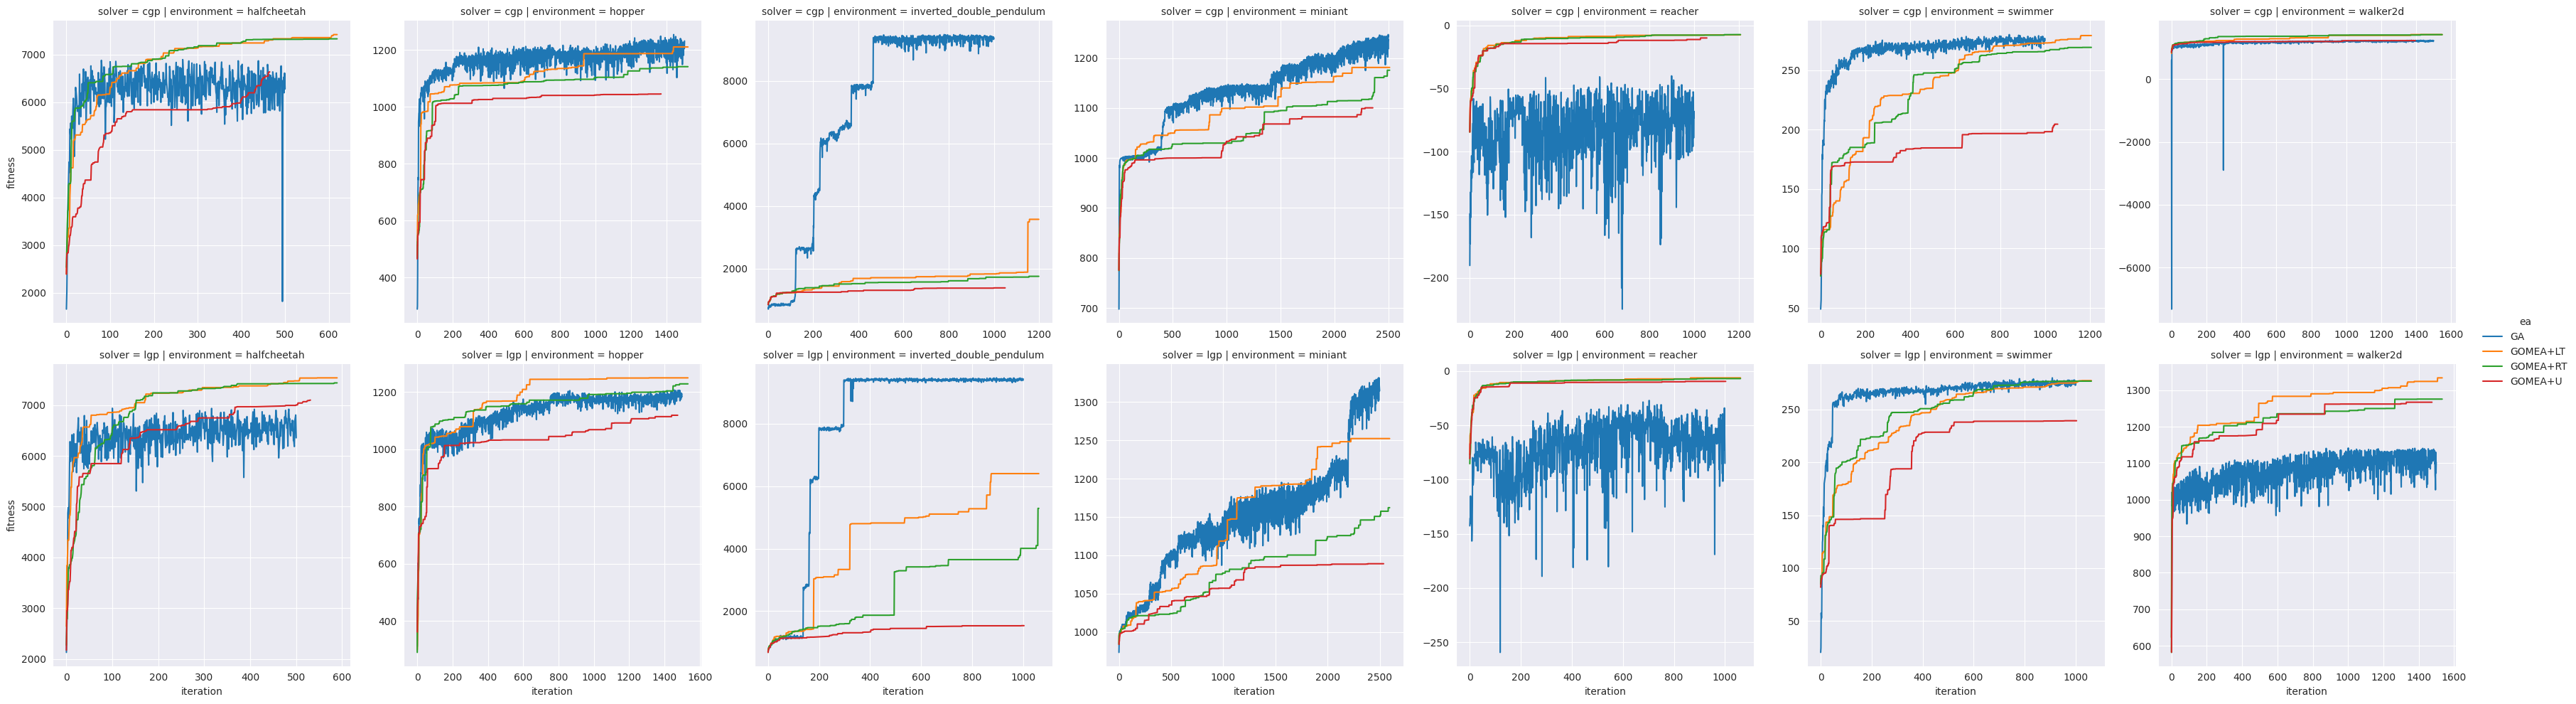

In [4]:
agg_df = (
    control_df
    .groupby(["environment", "solver", "ea", "iteration"])
    .mean()
    .reset_index()
)
g = sns.relplot(
    data=agg_df,
    x="iteration",
    y="fitness",
    # style="ea",
    hue="ea",
    col="environment",
    row="solver",
    # col_wrap=4,
    kind="line",
    # estimator=None,  #"median",
    errorbar=None,
    facet_kws=dict(sharey=False, sharex=False),
)
plt.show()

# Boolean Problems

In [5]:
it_max = 4999
boolean_dfs = []
for ea in ["ga", "gomea-LT", "gomea-RT", "gomea-U"]:
    for seed in range(5):
        for solver in ["lgp", "cgp"]:
            for problem in ["adder", "multiplier"]:
                if ea == "ga":
                    curr_ea = ea
                    fos = ""
                else:
                    curr_ea = ea.split("-")[0]
                    fos = ea.split("-")[1] + "_"
                bool_df = pd.read_csv(f"../results/{curr_ea}_{solver}_two_bit_{problem}_{fos}{seed}.csv")
                bool_df["seed"] = seed
                bool_df["ea"] = ea
                bool_df["solver"] = solver
                bool_df["problem"] = problem
                if len(bool_df[bool_df["iteration"] == "iteration"]) > 0:
                    bool_df = bool_df.loc[bool_df["iteration"].eq("iteration").idxmax() + 1:]
                boolean_dfs.append(bool_df)
                curr_max_it = int(max(bool_df["iteration"]))
                if curr_max_it < it_max:
                    last_row = bool_df.iloc[-1].copy()
                    for i in range(curr_max_it + 1, it_max + 1):
                        new_row = last_row.copy()
                        new_row["iteration"] = i
                        boolean_dfs.append(pd.DataFrame([new_row]))
boolean_df = pd.concat(boolean_dfs, ignore_index=True)
boolean_df.head()

,iteration,fitness,time,seed,ea,solver,problem
0,0,0.75,0.24,0,ga,lgp,adder
1,1,0.75,0.15,0,ga,lgp,adder
2,2,0.791667,0.16,0,ga,lgp,adder
3,3,0.791667,0.15,0,ga,lgp,adder
4,4,0.791667,0.15,0,ga,lgp,adder


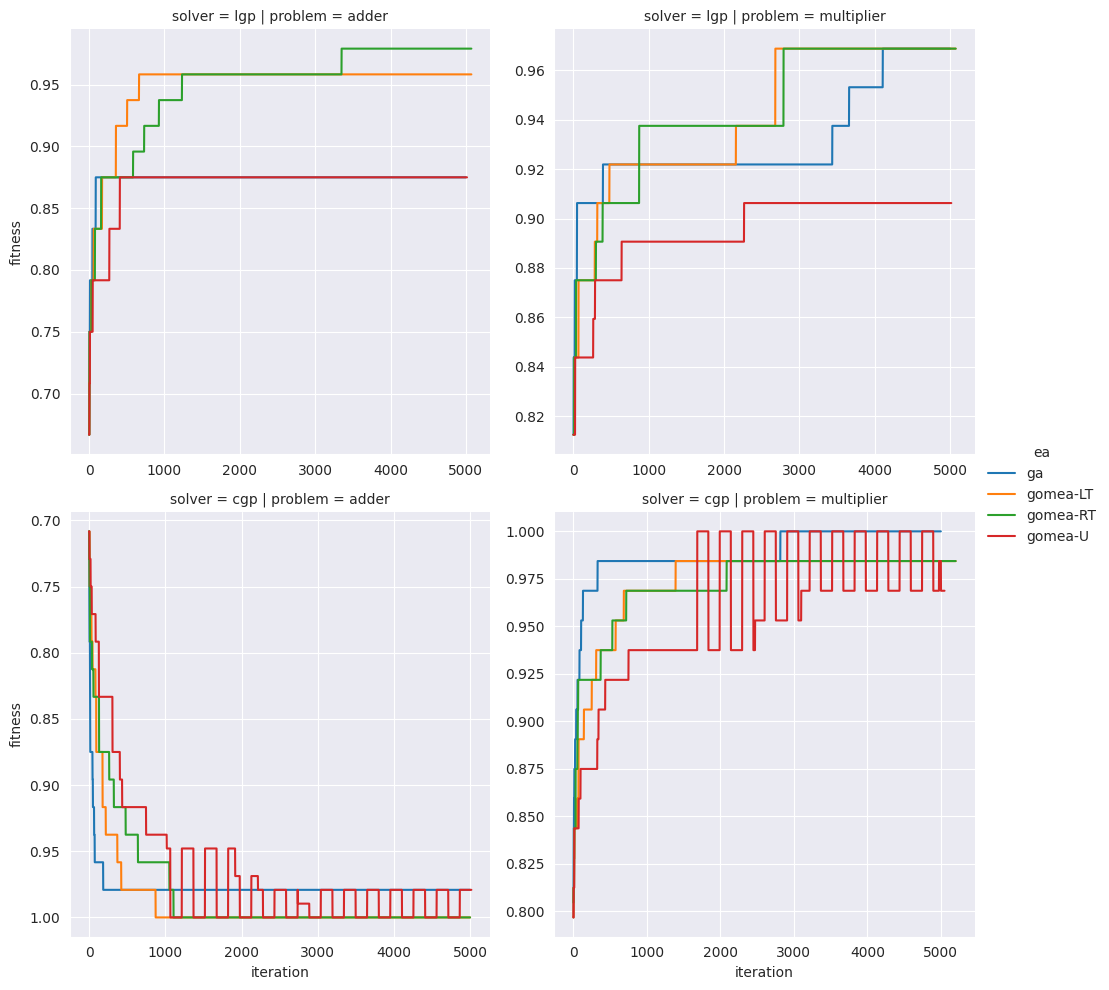

In [6]:
g = sns.relplot(
    data=boolean_df,
    x="iteration",
    y="fitness",
    # style="ea",
    hue="ea",
    col="problem",
    row="solver",
    # col_wrap=4,
    kind="line",
    estimator="median",
    errorbar=None,  #("pi", 50),
    facet_kws=dict(sharey=False, sharex=False)
)
plt.show()

# Discrete Control Problems

In [8]:
discrete_envs = ["Acrobot-v1", "CartPole-v1", "LunarLander-v2", "MountainCar-v0"]
discrete_dfs = []
for env in discrete_envs:
    for seed in range(100, 105):
        for solver in ["lgp", "cgp"]:
            for ea in ["ga", "gomea-U", "gomea-LT", "gomea-RT"]:
                processed_env_name = env.lower().split("-")[0]
                curr_ea = ea.split("-")[0]
                fos = "" if curr_ea == "ga" else ea.split("-")[1] + "_"
                df = pd.read_csv(f"../results/{curr_ea}_{solver}_{processed_env_name}_{fos}{seed}.csv")
                df["seed"] = seed
                df["ea"] = ea
                df["solver"] = solver
                df["problem"] = processed_env_name
                discrete_dfs.append(df)
discrete_df = pd.concat(discrete_dfs, ignore_index=True)
discrete_df.head()

,iteration,fitness,time,seed,ea,solver,problem
0,0,-70.599998,1.57,100,ga,lgp,acrobot
1,1,-98.000000,1.58,100,ga,lgp,acrobot
2,2,-69.000000,1.52,100,ga,lgp,acrobot
3,3,-69.400002,1.60,100,ga,lgp,acrobot
4,4,-69.599998,1.59,100,ga,lgp,acrobot


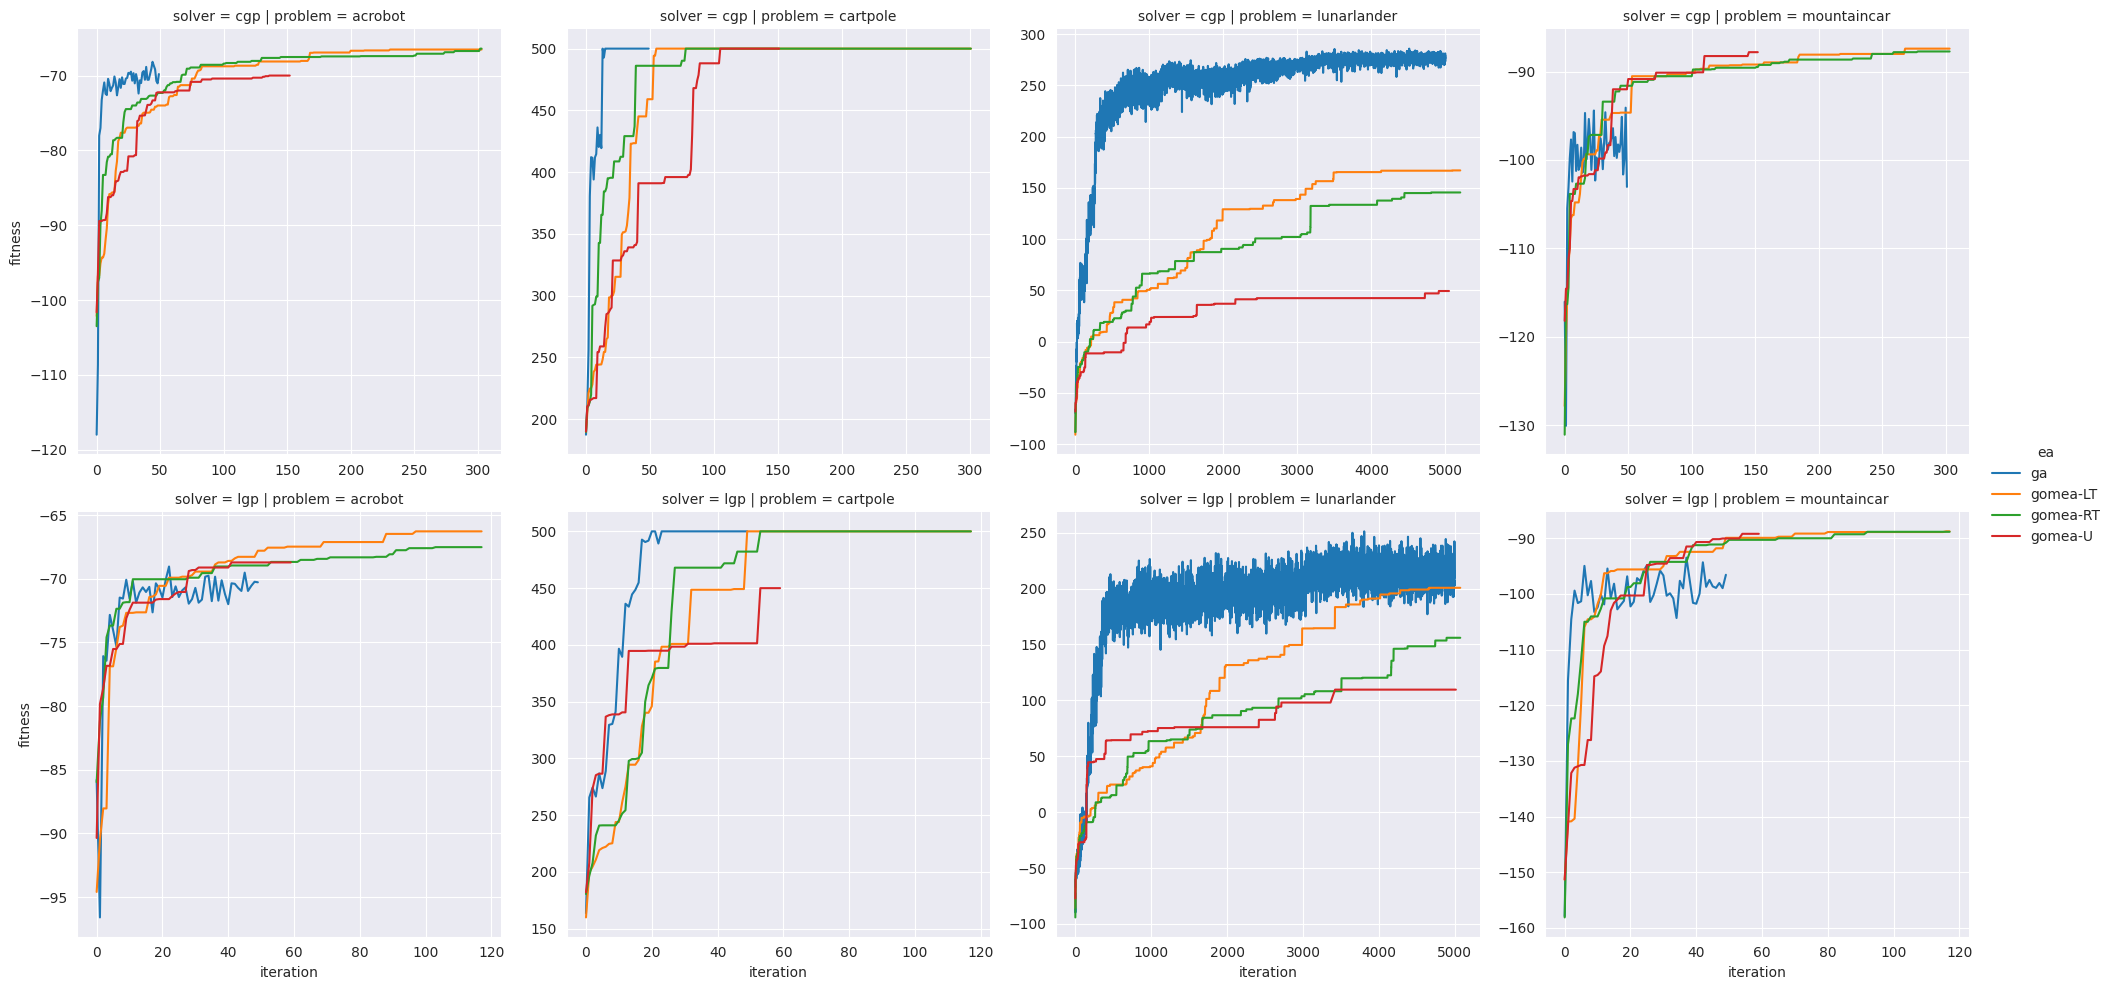

In [11]:
agg_disc_df = (
    discrete_df
    .groupby(["problem", "solver", "ea", "iteration"])
    .mean()
    .reset_index()
)
g = sns.relplot(
    data=agg_disc_df,
    x="iteration",
    y="fitness",
    # style="ea",
    hue="ea",
    col="problem",
    row="solver",
    # col_wrap=4,
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    facet_kws=dict(sharey=False, sharex=False)
)
plt.show()

# Classification Problems

In [15]:
classification_tasks = ["breast_cancer"]
classification_dfs = []
for ds in classification_tasks:
    for seed in range(5):
        for solver in ["lgp", "cgp"]:
            for ea in ["ga", "gomea-U", "gomea-RT", "gomea-LT"]:
                if ea == "ga":
                    curr_ea = ea
                    fos = ""
                else:
                    curr_ea = ea.split("-")[0]
                    fos = ea.split("-")[1] + "_"
                df = pd.read_csv(f"../results/{curr_ea}_{solver}_{ds}_{fos}{seed}.csv")
                df["seed"] = seed
                df["ea"] = ea
                df["solver"] = solver
                df["problem"] = ds
                classification_dfs.append(df)
classification_df = pd.concat(classification_dfs, ignore_index=True)
classification_df.head()

,iteration,fitness,test_accuracy,time,seed,ea,solver,problem
0,0,0.876923,0.877193,0.36,0,ga,lgp,breast_cancer
1,1,0.920879,0.894737,0.28,0,ga,lgp,breast_cancer
2,2,0.920879,0.894737,0.36,0,ga,lgp,breast_cancer
3,3,0.920879,0.894737,0.62,0,ga,lgp,breast_cancer
4,4,0.920879,0.894737,0.61,0,ga,lgp,breast_cancer


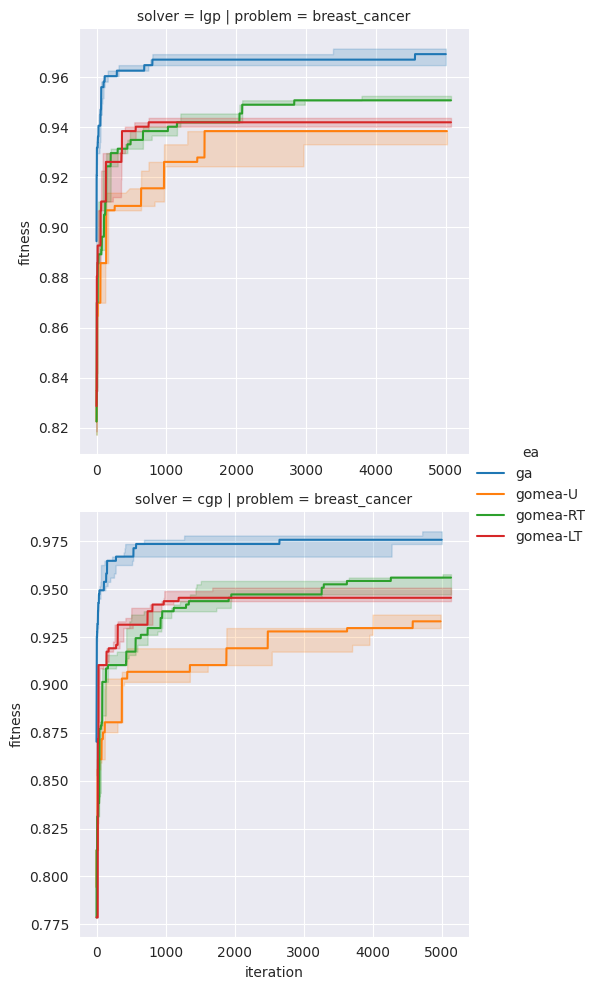

In [16]:
g = sns.relplot(
    data=classification_df,
    x="iteration",
    y="fitness",
    # style="ea",
    hue="ea",
    col="problem",
    row="solver",
    # col_wrap=4,
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    facet_kws=dict(sharey=False, sharex=False)
)
plt.show()

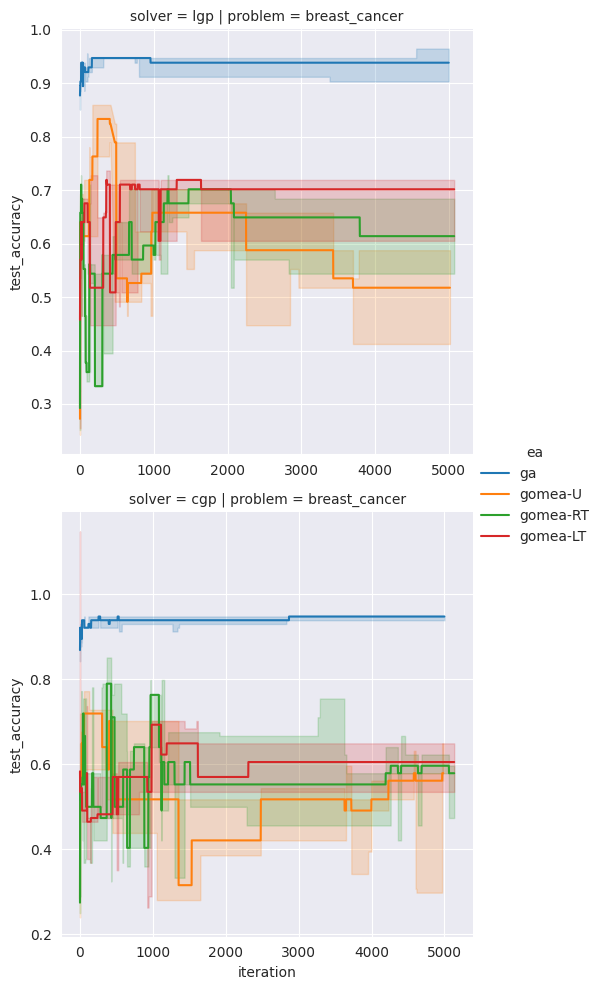

In [17]:
g = sns.relplot(
    data=classification_df,
    x="iteration",
    y="test_accuracy",
    # style="ea",
    hue="ea",
    col="problem",
    row="solver",
    # col_wrap=4,
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    facet_kws=dict(sharey=False, sharex=False)
)
plt.show()